# Guia de Feature Engineering com dados de várias modalidades

Sumário:

1. Dados tabulares
2. Dados de data
3. Dados de séries temporais
4. Dados espaciais
5. Dados de texto
6. Dados de imagens

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1) Dados tabulares

In [ ]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)

iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
X = iris['data']
y = iris['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


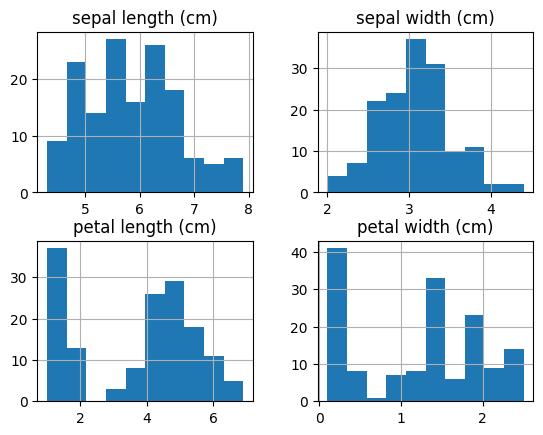

In [ ]:
print(list(X.columns))

X.hist();

<Axes: ylabel='target'>

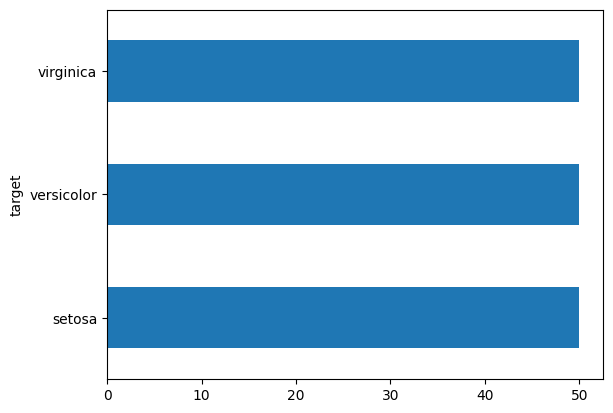

In [ ]:
y.value_counts().plot(kind='barh')

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (150). n_quantiles is set to n_samples.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (150). n_quantiles is set to n_samples.
  warnings.warn(


Text(0.5, 1.0, 'QuantileTransformer')

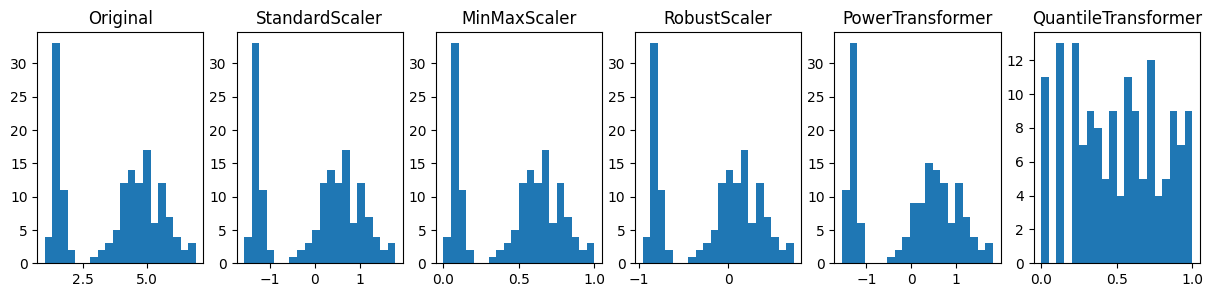

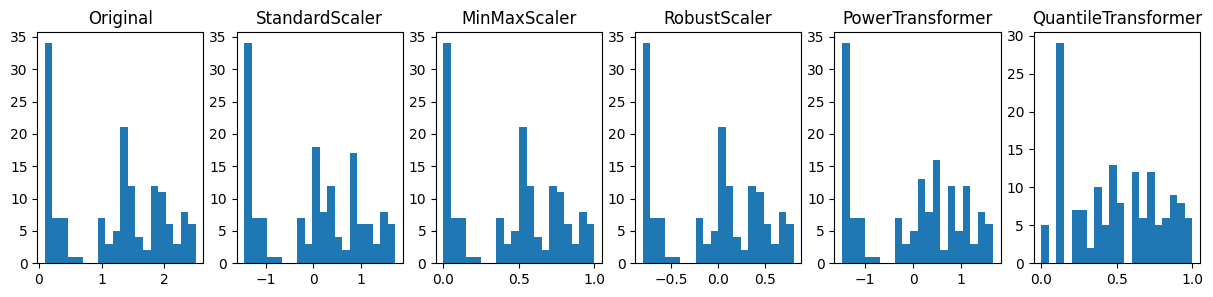

In [ ]:
# Normalização/Transformação de dados
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, QuantileTransformer

# Testing them all on the 'petal length (cm)' column
fig, ax = plt.subplots(1, 6, figsize=(15, 3))
ax[0].hist(X['petal length (cm)'], bins=20)
ax[0].set_title('Original')
ax[1].hist(StandardScaler().fit_transform(X[['petal length (cm)']]), bins=20)
ax[1].set_title('StandardScaler')
ax[2].hist(MinMaxScaler().fit_transform(X[['petal length (cm)']]), bins=20)
ax[2].set_title('MinMaxScaler')
ax[3].hist(RobustScaler().fit_transform(X[['petal length (cm)']]), bins=20)
ax[3].set_title('RobustScaler')
ax[4].hist(PowerTransformer().fit_transform(X[['petal length (cm)']]), bins=20)
ax[4].set_title('PowerTransformer')
ax[5].hist(QuantileTransformer().fit_transform(X[['petal length (cm)']]), bins=20)
ax[5].set_title('QuantileTransformer')

# Testing them all on the 'petal width (cm)' column
fig, ax = plt.subplots(1, 6, figsize=(15, 3))
ax[0].hist(X['petal width (cm)'], bins=20)
ax[0].set_title('Original')
ax[1].hist(StandardScaler().fit_transform(X[['petal width (cm)']]), bins=20)
ax[1].set_title('StandardScaler')
ax[2].hist(MinMaxScaler().fit_transform(X[['petal width (cm)']]), bins=20)
ax[2].set_title('MinMaxScaler')
ax[3].hist(RobustScaler().fit_transform(X[['petal width (cm)']]), bins=20)
ax[3].set_title('RobustScaler')
ax[4].hist(PowerTransformer().fit_transform(X[['petal width (cm)']]), bins=20)
ax[4].set_title('PowerTransformer')
ax[5].hist(QuantileTransformer().fit_transform(X[['petal width (cm)']]), bins=20)
ax[5].set_title('QuantileTransformer')

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()

ohe.fit(y.values.reshape(-1, 1))

y_ohe = ohe.transform(y.values.reshape(-1, 1)).toarray()
y_ohe = pd.DataFrame(y_ohe, columns = ohe.categories_)

y_ohe.head()

,setosa,versicolor,virginica
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0


In [ ]:
# Polynomial features
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

poly.fit(X)

X_poly = poly.transform(X)
X_poly = pd.DataFrame(X_poly, columns = poly.get_feature_names_out())

X_poly.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),sepal length (cm)^2,sepal length (cm) sepal width (cm),sepal length (cm) petal length (cm),sepal length (cm) petal width (cm),sepal width (cm)^2,sepal width (cm) petal length (cm),sepal width (cm) petal width (cm),petal length (cm)^2,petal length (cm) petal width (cm),petal width (cm)^2
0,5.1,3.5,1.4,0.2,26.01,17.85,7.14,1.02,12.25,4.90,0.70,1.96,0.28,0.04
1,4.9,3.0,1.4,0.2,24.01,14.70,6.86,0.98,9.00,4.20,0.60,1.96,0.28,0.04
2,4.7,3.2,1.3,0.2,22.09,15.04,6.11,0.94,10.24,4.16,0.64,1.69,0.26,0.04
3,4.6,3.1,1.5,0.2,21.16,14.26,6.90,0.92,9.61,4.65,0.62,2.25,0.30,0.04
4,5.0,3.6,1.4,0.2,25.00,18.00,7.00,1.00,12.96,5.04,0.72,1.96,0.28,0.04


In [ ]:
# Feature selection

from sklearn.feature_selection import RFE
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

selector = RFE(RandomForestClassifier(), n_features_to_select=5, step=1)

selector.fit(X_poly.values, y.values)

X_poly_selected = X_poly[X_poly.columns[selector.support_]]
X_poly_selected.columns

Index(['petal length (cm)', 'petal width (cm)',
       'sepal length (cm) petal width (cm)',
       'petal length (cm) petal width (cm)', 'petal width (cm)^2'],
      dtype='object')

**Importante!**

Realizar train_test_split antes do feature engineering para evitar data leakage:

In [ ]:
# Pipeline where feature engineering is applied to training data and testing data separately

from sklearn.pipeline import Pipeline

pipeline = Pipeline(
    steps=[
        ('scaling', QuantileTransformer()),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('selector', RFE(SVC(kernel="linear"), n_features_to_select=5, step=1)),
    ]
)

# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# Fit pipeline to training data

pipeline.fit(X_train, y_train)

X_poly_selected_train = pipeline.transform(X_train)
X_poly_selected_test = pipeline.transform(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (75). n_quantiles is set to n_samples.
  warnings.warn(


In [ ]:
# Model training
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

model2 = DecisionTreeClassifier()
model2.fit(X_poly_selected_train, y_train)

# Accuracy on the test set
print(
    f"Model 1 (Vanilla) - Accuracy on the test set: {model.score(X_test, y_test):.3f}\n"
    f"Model 2 (FeatSel) - Accuracy on the test set: {model2.score(X_poly_selected_test, y_test):.3f}\n"
)

# Cross-validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=10)
print(f"Model 1 (Vanilla) - Cross-validation scores: {np.mean(scores):.3f}")
scores2 = cross_val_score(model2, X_poly_selected, y, cv=10)
print(f"Model 2 (FeatSel) - Cross-validation scores: {np.mean(scores2):.3f}")

Model 1 (Vanilla) - Accuracy on the test set: 0.973
Model 2 (FeatSel) - Accuracy on the test set: 0.933

Model 1 (Vanilla) - Cross-validation scores: 0.960
Model 2 (FeatSel) - Cross-validation scores: 0.967


In [ ]:
# Finally:

pipeline = Pipeline(
    steps=[
        ('scaling', QuantileTransformer(n_quantiles=20)),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('selector', RFE(SVC(kernel="linear"), n_features_to_select=5, step=1)),
        ('model', DecisionTreeClassifier()),
    ]
)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# Fit pipeline to training data
pipeline.fit(X_train, y_train)

# Accuracy on the test set
y_pred = pipeline.predict(X_test)
print(f"Accuracy on the test set: {pipeline.score(X_test, y_test):.3f}")

# Cross-validation
scores = cross_val_score(pipeline, X, y, cv=5)
print(f"Accuracy on cross-validation: {np.mean(scores):.3f}")

Accuracy on the test set: 0.947
Accuracy on cross-validation: 0.953


## 2) Dados de data

Codificação cíclica

In [ ]:
def codifica_ciclica(serie, periodo, nome):
    """Retorna DataFrame com seno e cosseno de 2*pi*t/T."""
    ang = 2 * np.pi * serie / periodo
    return pd.DataFrame({f"{nome}_sin": np.sin(ang), f"{nome}_cos": np.cos(ang)}, index=serie.index)

In [ ]:
dow = ['domingo', 'segunda', 'terça', 'quarta', 'quinta', 'sexta', 'sábado']

dow_serie = pd.Series(range(len(dow)), index=dow)

codifica_ciclica(pd.Series(range(len(dow)), index=dow), len(dow), 'dow')

,dow_sin,dow_cos
domingo,0.000000,1.000000
segunda,0.781831,0.623490
terça,0.974928,-0.222521
quarta,0.433884,-0.900969
quinta,-0.433884,-0.900969
sexta,-0.974928,-0.222521
sábado,-0.781831,0.623490


In [ ]:
hora_do_dia = list(range(24))

hora_serie = pd.Series(hora_do_dia)

codifica_ciclica(hora_serie, len(hora_do_dia), 'hora')

,hora_sin,hora_cos
0,0.000000e+00,1.000000e+00
1,2.588190e-01,9.659258e-01
2,5.000000e-01,8.660254e-01
3,7.071068e-01,7.071068e-01
4,8.660254e-01,5.000000e-01
5,9.659258e-01,2.588190e-01
6,1.000000e+00,6.123234e-17
7,9.659258e-01,-2.588190e-01
8,8.660254e-01,-5.000000e-01
9,7.071068e-01,-7.071068e-01


## 3) Séries temporais

<Axes: >

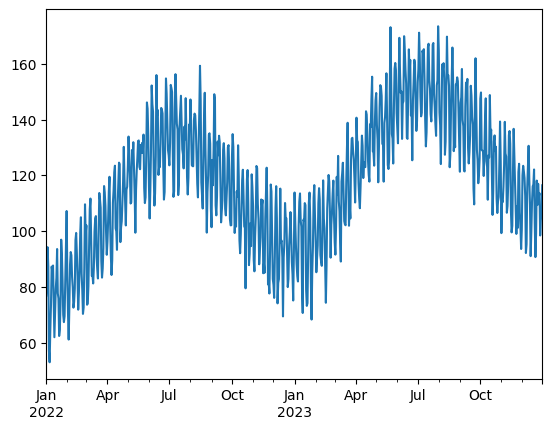

In [ ]:
# Numeros aleatorios amostrados durante 7 dias, amostrados por hora do dia

rng = np.random.default_rng(42)
datas = pd.date_range("2022-01-01", periods=730, freq="D")   # ~2 anos, diário
t = np.arange(len(datas))

tendencia = 100 + 0.05 * t                                     # crescimento lento
saz_semanal = 15 * np.sin(2 * np.pi * t / 7)                    # ciclo de 7 dias
saz_anual = 25 * np.sin(2 * np.pi * t / 365.25 - np.pi / 2)     # ciclo anual
ruido = rng.normal(0, 6, size=len(t))

serie = pd.Series(
    tendencia + saz_semanal + saz_anual + ruido,
    index=datas, name="demanda"
)

serie.plot()

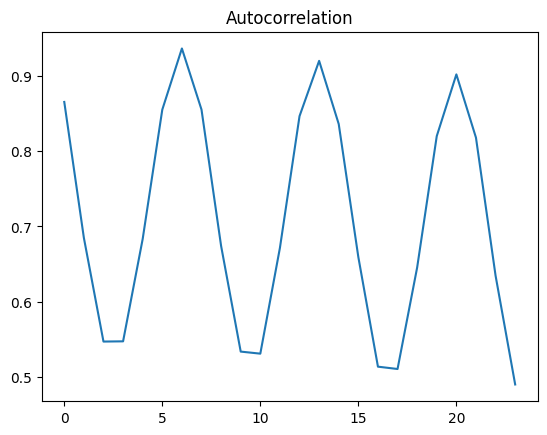

In [ ]:
# Autocorrelation with 24 lags

lags = 24
X_24lags = pd.concat([serie.shift(i+1).rename(f't-{i+1}') for i in range(lags)], axis=1)

correlations = pd.Series([serie.corr(X_24lags[f't-{i+1}']) for i in range(lags)], index=range(lags))

plot = correlations.plot()
plot.set_title("Autocorrelation");

In [ ]:
# Extração de lags (features autoregressivas)

X = pd.concat([serie.shift(i+1).rename(f't-{i+1}') for i in range(5)], axis=1)
X.head(10)

,t-1,t-2,t-3,t-4,t-5
2022-01-01,NaN,NaN,NaN,NaN,NaN
2022-01-02,76.828302,NaN,NaN,NaN,NaN
2022-01-03,80.541267,76.828302,NaN,NaN,NaN
2022-01-04,94.241421,80.541267,76.828302,NaN,NaN
2022-01-05,87.334928,94.241421,80.541267,76.828302,NaN
2022-01-06,57.044694,87.334928,94.241421,80.541267,76.828302
2022-01-07,52.905423,57.044694,87.334928,94.241421,80.541267
2022-01-08,64.472618,52.905423,57.044694,87.334928,94.241421
2022-01-09,73.633579,64.472618,52.905423,57.044694,87.334928
2022-01-10,87.263031,73.633579,64.472618,52.905423,57.044694


In [ ]:
def extract_lags(serie, lags, label='t'):
    """Retorna DataFrame com lags."""
    return pd.concat([serie.shift(i+1).rename(f'{label}-{i+1}') for i in range(lags)], axis=1)

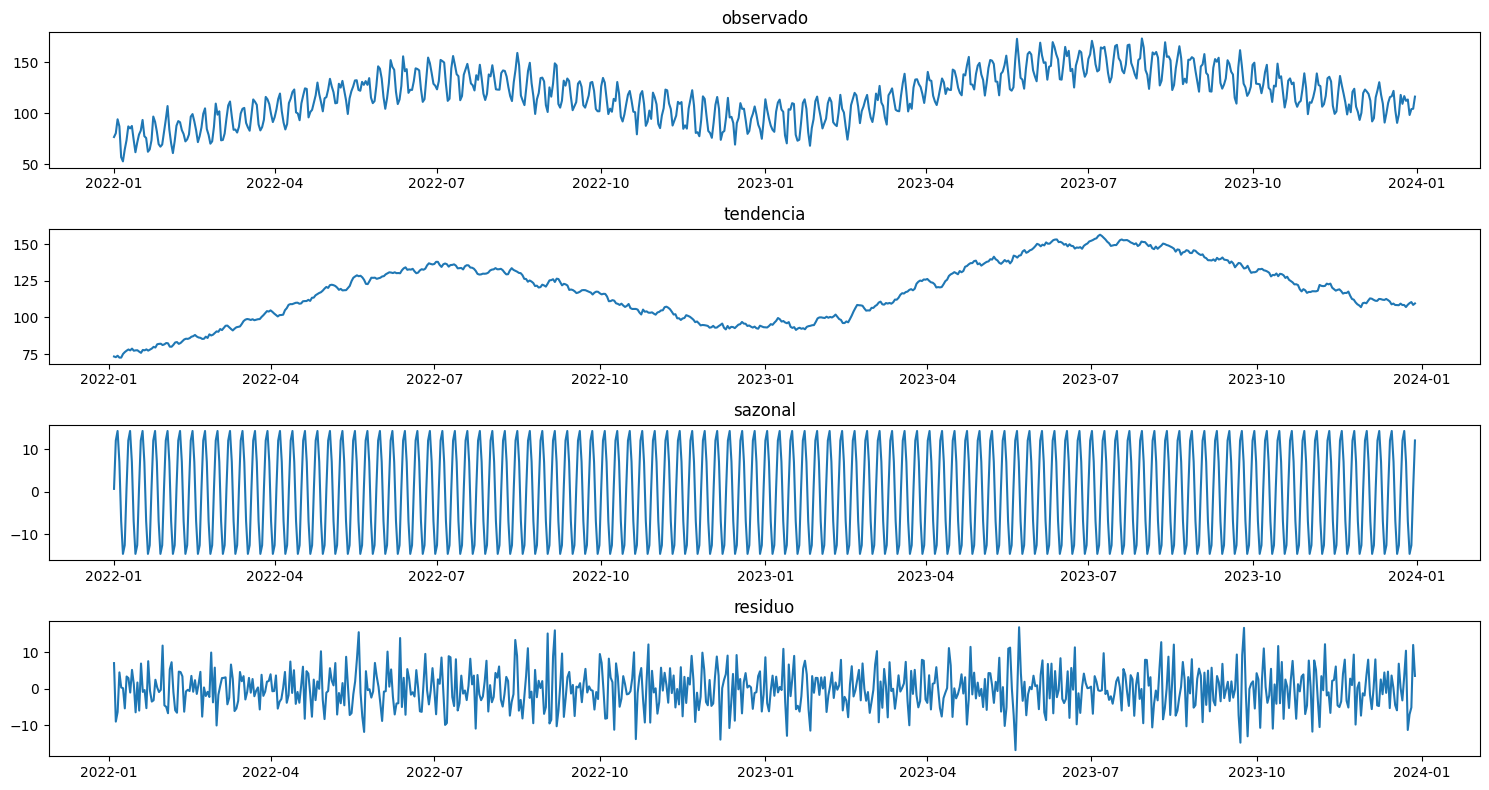

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decomposição aditiva com período semanal (7): y_t = T_t + S_t + R_t
dec = seasonal_decompose(serie, model="additive", period=7)

comp = pd.DataFrame({
    "observado": dec.observed,
    "tendencia": dec.trend,     # média móvel centrada de 7 dias -> NaN nas pontas
    "sazonal": dec.seasonal,    # padrão médio de cada dia da semana
    "residuo": dec.resid,
})

fig, ax = plt.subplots(4, 1, figsize=(15, 8))
for i, col in enumerate(comp.columns):
    ax[i].plot(comp[col])
    ax[i].set_title(col)
fig.tight_layout()

In [ ]:
n_lags = 7

X_observado = extract_lags(dec.observed, n_lags, label='Obsvd_t')
X_tendencia = extract_lags(dec.trend, n_lags, label='Trend_t')
X_sazonal = extract_lags(dec.seasonal, n_lags, label='Seas_t')

X_sarma = pd.concat([X_observado, X_tendencia, X_sazonal], axis=1)
X_sarma = X_sarma.dropna()

X_sarma.head()

,Obsvd_t-1,Obsvd_t-2,Obsvd_t-3,Obsvd_t-4,Obsvd_t-5,Obsvd_t-6,Obsvd_t-7,Trend_t-1,Trend_t-2,Trend_t-3,...,Trend_t-5,Trend_t-6,Trend_t-7,Seas_t-1,Seas_t-2,Seas_t-3,Seas_t-4,Seas_t-5,Seas_t-6,Seas_t-7
2022-01-11,85.254680,87.263031,73.633579,64.472618,52.905423,57.044694,87.334928,76.333618,75.048245,72.603952,...,73.842242,72.881990,73.338379,14.279973,12.056969,0.683491,-12.555565,-14.589549,-6.867656,6.992338
2022-01-12,87.653637,85.254680,87.263031,73.633579,64.472618,52.905423,57.044694,77.310175,76.333618,75.048245,...,72.558422,73.842242,72.881990,6.992338,14.279973,12.056969,0.683491,-12.555565,-14.589549,-6.867656
2022-01-13,74.154746,87.653637,85.254680,87.263031,73.633579,64.472618,52.905423,78.109173,77.310175,76.333618,...,72.603952,72.558422,73.842242,-6.867656,6.992338,14.279973,12.056969,0.683491,-12.555565,-14.589549
2022-01-14,61.903039,74.154746,87.653637,85.254680,87.263031,73.633579,64.472618,77.521511,78.109173,77.310175,...,75.048245,72.603952,72.558422,-14.589549,-6.867656,6.992338,14.279973,12.056969,0.683491,-12.555565
2022-01-15,71.308512,61.903039,74.154746,87.653637,85.254680,87.263031,73.633579,78.710473,77.521511,78.109173,...,76.333618,75.048245,72.603952,-12.555565,-14.589549,-6.867656,6.992338,14.279973,12.056969,0.683491


In [ ]:
X_sarma.shape, serie.shape

((718, 21), (730,))

In [ ]:
# Train model

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_sarma, serie[n_lags+5:])

# Predict
# ...

LinearRegression()

## 4) Dados espaciais

In [ ]:
! pip install osmnx --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 4.0 MB/s eta 0:00:00


In [ ]:
import osmnx as ox
import geopandas as gpd
from shapely.geometry import Point, Polygon, MultiPoint

def get_city_shape(place_query):
    """Busca o shape (polígono) de uma cidade/região via OSM.

    Parameters
    ----------
    place_query : str
        Nome do lugar, no formato aceito pelo Nominatim.
        Ex: "Natal, RN, Brazil", "Rio Grande do Norte, Brazil".

    Returns
    -------
    geopandas.GeoDataFrame
        GeoDataFrame com 1 linha (ou mais, se a busca for ambígua) contendo
        a geometria (Polygon/MultiPolygon) do lugar.

    Example
    -------
    >>> city = get_city_shape("Natal, RN, Brazil")
    >>> city.geometry.iloc[0]  # shapely Polygon/MultiPolygon
    """
    return ox.geocode_to_gdf(place_query)


def get_pois(city_gdf, **map_features):
    """Busca pontos-de-interesse (POIs) dentro do shape de uma cidade.

    Parameters
    ----------
    city_gdf : geopandas.GeoDataFrame
        Resultado de `get_city_shape`, ou qualquer GeoDataFrame cuja
        primeira geometria delimite a área de busca.
    **map_features : kwargs
        Chaves/valores do OSM (https://wiki.openstreetmap.org/wiki/Map_Features).
        Um valor `True` pega qualquer item daquela chave (equivalente ao "*"
        do geohunter antigo); uma lista pega só os itens especificados.
        Ex: amenity=["school", "hospital"], natural=True, highway="primary".

    Returns
    -------
    geopandas.GeoDataFrame
        GeoDataFrame com os POIs encontrados (pontos, linhas e/ou polígonos).

    Example
    -------
    >>> city = get_city_shape("Natal, RN, Brazil")
    >>> pois = get_pois(city, amenity=["school", "hospital"], natural=True)
    """
    polygon = city_gdf.geometry.iloc[0]
    return ox.features_from_polygon(polygon, tags=map_features)


def plot(city_gdf, pois_gdf=None):
    """Plota o shape da cidade e, opcionalmente, os POIs sobre ele."""
    ax = city_gdf.boundary.plot(color="black")
    if pois_gdf is not None and len(pois_gdf) > 0:
        pois_gdf.plot(ax=ax, column="element_type", legend=True, markersize=6)
    return ax

def create_gridsquares(city_shape, resolution=1):
    """Constructs a grid of square cells.

    Parameters
    ----------
    city_shape : GeoDataFrame.
        Corresponds to the boundary geometry in which the grid will be formed.

    resolution : float, default is 1.
        Space between the square cells.
    """
    x0 = city_shape.bounds.min().values[0]
    xf = city_shape.bounds.max().values[2]
    y0 = city_shape.bounds.min().values[1]
    yf = city_shape.bounds.max().values[3]
    n_y = int((yf-y0)/(resolution/110.57))
    n_x = int((xf-x0)/(resolution/111.32))
    grid = {}
    c = 0
    for i in range(n_x):
        for j in range(n_y):
            grid[c] = {'geometry':Polygon([[x0,y0],
                            [x0+(resolution/111.32),y0],
                            [x0+(resolution/111.32),y0+(resolution/110.57)],
                            [x0,y0+(resolution/110.57)]])}
            c += 1
            y0 += resolution/110.57
        y0 = city_shape.bounds.min().values[1]
        x0 += resolution/111.32
    grid = pd.DataFrame(grid).transpose()
    grid = gpd.GeoDataFrame(grid)
    grid.crs = {'init': 'epsg:4326'}
    grid = grid.to_crs(city_shape.crs)
    grid = gpd.sjoin(grid, city_shape,
                     predicate='intersects')[grid.columns]
    grid['lat'] = grid.centroid.y
    grid['lon'] = grid.centroid.x
    grid.index.name = 'places'
    return grid[~grid.index.duplicated()]



<Axes: >

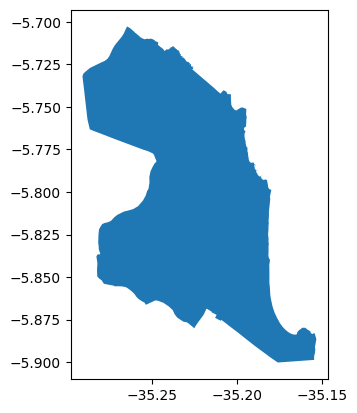

In [ ]:
city = get_city_shape("Natal, RN, Brazil")
city.plot()

/usr/local/lib/python3.13/dist-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/tmp/ipykernel_1727/1542463317.py:98: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  grid['lat'] = grid.centroid.y
/tmp/ipykernel_1727/1542463317.py:99: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  grid['lon'] = grid.centroid.x


<Axes: >

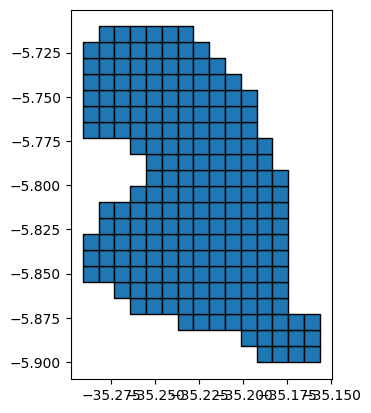

In [ ]:
grid_squares = create_gridsquares(city)
grid_squares.plot(edgecolor='black')

/usr/local/lib/python3.13/dist-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/tmp/ipykernel_1727/2202467969.py:59: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: +init=epsg:4326 +type=crs
Right CRS: EPSG:4326

  grid = gpd.sjoin(grid, bbox, predicate='intersects')[grid.columns].drop_duplicates()
/tmp/ipykernel_1727/2202467969.py:61: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  grid['lon'] = grid['geo

<Axes: >

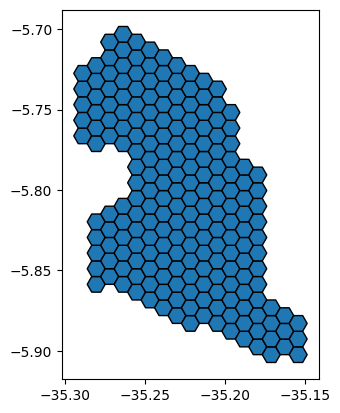

In [ ]:
import math

def create_hexagon(l, x, y):
    """
    Create a hexagonal polygon.

    Args:
        l (float): Length of hexagon side
        x (float): X-coordinate of center
        y (float): Y-coordinate of center

    Returns:
        Polygon: Hexagonal polygon
    """
    c = [[x + math.cos(math.radians(angle)) * l, y + math.sin(math.radians(angle)) * l] for angle in range(0, 360, 60)]
    return Polygon(c)

def create_gridhexagonal(bbox, resolution):

    assert resolution > 0, \
        "Invalid resolution."
    resolution = ((resolution)**2 * (2/(3*(3**0.5)))) ** 0.5 # normalize resolution to have the same area as if it was a square
    assert isinstance(bbox, gpd.GeoDataFrame), \
        'bbox must be geopandas GeoDataFrame.'
    bbox_ = list(bbox.bounds.min().values[:2]) + list(bbox.bounds.max().values[-2:])
    x_min = min(bbox_[0], bbox_[2])
    x_max = max(bbox_[0], bbox_[2])
    y_min = min(bbox_[1], bbox_[3])
    y_max = max(bbox_[1], bbox_[3])
    grid = []
    resolution = resolution/110.6
    v_step = math.sqrt(3) * resolution
    h_step = 1.5 * resolution
    h_skip = math.ceil(x_min / h_step) - 1
    h_start = h_skip * h_step
    v_skip = math.ceil(y_min / v_step) - 1
    v_start = v_skip * v_step
    h_end = x_max + h_step
    v_end = y_max + v_step
    if v_start - (v_step / 2.0) < y_min:
        v_start_array = [v_start + (v_step / 2.0), v_start]
    else:
        v_start_array = [v_start - (v_step / 2.0), v_start]
    v_start_idx = int(abs(h_skip) % 2)
    c_x = h_start
    c_y = v_start_array[v_start_idx]
    v_start_idx = (v_start_idx + 1) % 2
    while c_x < h_end:
        while c_y < v_end:
            grid.append(create_hexagon(resolution, c_x, c_y))
            c_y += v_step
        c_x += h_step
        c_y = v_start_array[v_start_idx]
        v_start_idx = (v_start_idx + 1) % 2
    grid = gpd.GeoDataFrame(geometry=grid).reset_index()
    grid.crs = {'init': 'epsg:4326'}
    grid = grid.rename(columns={'index':'places'}).set_index('places')
    if isinstance(bbox, gpd.GeoDataFrame):
        grid = gpd.sjoin(grid, bbox, predicate='intersects')[grid.columns].drop_duplicates()
        grid = grid.to_crs(bbox.crs)
    grid['lon'] = grid['geometry'].centroid.x
    grid['lat'] = grid['geometry'].centroid.y
    return grid

grid_hex = create_gridhexagonal(city, resolution=1)
grid_hex.plot(edgecolor='black')

275 POIs encontrados


<Axes: >

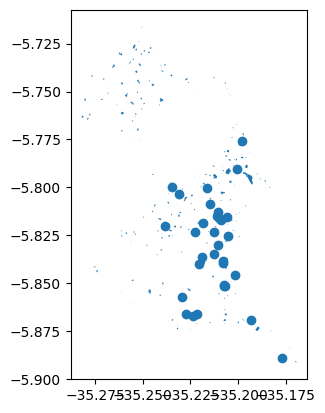

In [ ]:
pois = get_pois(city, amenity=["school"])
print(f"{len(pois)} POIs encontrados")

pois.plot()

In [ ]:
counts = gpd.sjoin(pois, grid_squares, predicate='intersects').groupby('places').size().rename('count')

counts_grid = grid_squares.join(counts).fillna(0)

counts_grid['count']

,count
places,
5,0.0
6,0.0
7,0.0
14,0.0
15,0.0
...,...
274,2.0
275,0.0
294,0.0


<Axes: >

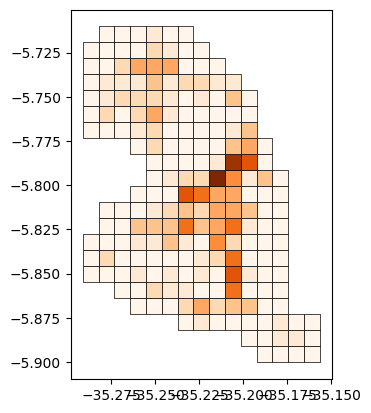

In [ ]:
counts = gpd.sjoin(pois, grid_squares, predicate='intersects').groupby('places').size().rename('count')

counts_grid = grid_squares.join(counts).fillna(0)

counts_grid.plot(
    column='count',          # <-- Replace with your column name
    cmap='Oranges',            # Choice of color palette (e.g., 'viridis', 'coolwarm')
    edgecolor='black',         # Adds polygon borders
    linewidth=0.5
)

## 5) Dados de texto

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Define a simple corpus
documents = [
    "I love coding in Python.",
    "Python is fun and powerful.",
    "I love learning new things every day."
]

# Initialize the vectorizer
vectorizer = TfidfVectorizer()

# Fit and transform the documents into a TF-IDF matrix
tfidf_matrix = vectorizer.fit_transform(documents)

# View the resulting array
pd.DataFrame(tfidf_matrix.toarray(), index=documents,
             columns=vectorizer.get_feature_names_out())

,and,coding,day,every,fun,in,is,learning,love,new,powerful,python,things
I love coding in Python.,0.000000,0.562829,0.000000,0.000000,0.000000,0.562829,0.000000,0.000000,0.428046,0.000000,0.000000,0.428046,0.000000
Python is fun and powerful.,0.467351,0.000000,0.000000,0.000000,0.467351,0.000000,0.467351,0.000000,0.000000,0.000000,0.467351,0.355432,0.000000
I love learning new things every day.,0.000000,0.000000,0.423394,0.423394,0.000000,0.000000,0.000000,0.423394,0.322002,0.423394,0.000000,0.000000,0.423394


In [ ]:
! pip install tensorflow tensorflow-hub tensorflow-text --quiet

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
# CRITICAL: Even if you don't call text_modules explicitly,
# you MUST import tensorflow_text to register the required ops in the background.
import tensorflow_text

# 1. Define the model handle (Multilingual MUSE v3)
# You can also use the '-large' version depending on your accuracy needs
model_url = "https://tfhub.dev/google/universal-sentence-encoder-multilingual/3"

# 2. Load the model via TensorFlow Hub
print("Loading Multilingual USE model...")
encoder = hub.load(model_url)
print("Model loaded successfully!")

Loading Multilingual USE model...
Model loaded successfully!


In [ ]:
# 3. Define multilingual inputs
text_inputs = [
    "I love coding in Python.",             # English
    "Me encanta programar en Python.",      # Spanish
    "Eu amo programar em Python.",          # Portuguese
    "J'aime programmer en Python."          # French
]

# 4. Extract features
# Convert to a tf.constant tensor or pass a standard python list
embeddings = encoder(text_inputs)

# 5. Convert tensors back to an easy-to-use NumPy array
features_matrix = embeddings.numpy()

print(f"Features Matrix Shape: {features_matrix.shape}")
pd.DataFrame(features_matrix, index=text_inputs)

Features Matrix Shape: (4, 512)


,0,1,2,3,4,5,6,7,8,9,...,502,503,504,505,506,507,508,509,510,511
I love coding in Python.,-0.025136,0.006088,0.032814,0.034252,-0.071156,-0.080008,0.031555,0.006500,-0.044428,0.038806,...,0.005107,-0.027044,0.035758,-0.080094,-0.038599,0.004891,-0.061003,0.025048,0.007533,0.060075
Me encanta programar en Python.,-0.012988,-0.029565,-0.025851,0.027401,-0.068235,-0.076100,0.015623,0.040888,-0.070047,0.026839,...,-0.014867,-0.038559,0.026393,-0.075026,-0.020455,-0.003693,-0.046284,-0.020140,0.008496,0.051525
Eu amo programar em Python.,-0.022946,-0.040663,-0.020319,0.049853,-0.073671,-0.077456,0.012288,0.023843,-0.065497,0.019868,...,-0.005267,-0.021197,0.044533,-0.075756,-0.019418,0.025585,-0.041918,-0.009474,-0.020436,0.037857
J'aime programmer en Python.,-0.013213,-0.007602,0.008144,0.040851,-0.068563,-0.077024,0.037148,0.049492,-0.068410,0.008738,...,-0.002342,-0.045996,0.048166,-0.071610,-0.011126,0.049040,-0.019468,-0.012969,0.010363,0.038834


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# ... (Assuming 'features_matrix' from the previous steps) ...

labels = ["EN: Python", "ES: Python", "PT: Python", "FR: Python"]
num_docs = len(labels)

# Use a nested loop to compare every document to every other document
for i in range(num_docs):
    for j in range(num_docs):
        # Reshape to (1, -1) because sklearn expects a 2D array for single rows
        vec_i = features_matrix[i].reshape(1, -1)
        vec_j = features_matrix[j].reshape(1, -1)

        # Calculate similarity
        score = cosine_similarity(vec_i, vec_j)[0][0]

        print(f"Similarity between [{labels[i]}] and [{labels[j]}]: {score:.4f}")


Similarity between [EN: Python] and [EN: Python]: 1.0000
Similarity between [EN: Python] and [ES: Python]: 0.8340
Similarity between [EN: Python] and [PT: Python]: 0.8447
Similarity between [EN: Python] and [FR: Python]: 0.8396
Similarity between [ES: Python] and [EN: Python]: 0.8340
Similarity between [ES: Python] and [ES: Python]: 1.0000
Similarity between [ES: Python] and [PT: Python]: 0.9588
Similarity between [ES: Python] and [FR: Python]: 0.8905
Similarity between [PT: Python] and [EN: Python]: 0.8447
Similarity between [PT: Python] and [ES: Python]: 0.9588
Similarity between [PT: Python] and [PT: Python]: 1.0000
Similarity between [PT: Python] and [FR: Python]: 0.8852
Similarity between [FR: Python] and [EN: Python]: 0.8396
Similarity between [FR: Python] and [ES: Python]: 0.8905
Similarity between [FR: Python] and [PT: Python]: 0.8852
Similarity between [FR: Python] and [FR: Python]: 1.0000


## 6) Dados de imagens

In [ ]:
# ...